# Introduction to MobGap and Data Science

This exercise is a basic introduction to what we do as researchers in mobility data analysis. Today, you should have already been down to our lab and had a look at the motion capture system, along with some wearable sensors. 

This notebook is comprised of 'cells' of code which you can run one at a time by clicking the play button at the top with that cell highlighted. This notebook will guide you through how we analyse mobility data from wearable sensors, along with the specific tools and libraries we use, and how we can visualise and explore these outcomes with graphs and plots.

## 1. Importing Libraries
In Python, we use libraries full of prewritten code to save us having to write everything from scratch each time we use it. This saves us an enourmous amount of time. For this project, we will use the library "MobGap" which was developped during a big research project called "Mobilise-D". You can find out more about Mobilise-D here: https://mobilise-d.eu/

When we import libraries, we have 3 options. We can import the library like so:

```import mobgap```

We can rename the library as we import it:

```import mobgap as whatever_i_want_to_call_it```

Or, we can import specific functions and objects from the library:

```from mobgap import function_or_object```

Now, mobgap is a huge library and, just like a real library, inside you'll find lots of invidiual files which each do specific things. If we want to import a specific function inside a specific file inside mobgap, we can reference it like so:

```from mobgap.file import function_inside_file```

You'll see this below, where we look inside the "data" file inside of mobgap, and import the "GenericMobilisedDataset" object, which allows us to consruct a dataset from some data files.

Run the cell below to import these functions from the mobgap library so that we can use them later:

In [1]:
from mobgap.data import GenericMobilisedDataset
from mobgap.pipeline import MobilisedPipelineHealthy

C:\Users\ac4jmi\anaconda3\envs\mobgap_fixed\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ac4jmi\anaconda3\envs\mobgap_fixed\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\ac4jmi\anaconda3\envs\mobgap_fixed\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/

## 2. Getting our Data into a MobGap Dataset
Next, let's get our data that we collected in the lab into MobGap so that we can analyse it and run our "MobilisedPipelineHealthy" function that we imported earlier on the data.

### 2.1. What is a CWA?
You may be familiar with binary as the form in which data is stored in a computer. Well, binary is a _very_ efficient way of stoing this data compared with something like a ".txt" or Excel file. Think about Excel for a moment, when you have a number you want to store in there, you can't just store the number, you also need to store:
- What cell the number is in
- The font of the number
- The font size of the number
- The colour of the font of the number

This is not efficient. As such, we choose to store our data in a super-efficient ".cwa" file, which is mostly just binary. The down-side of this is that the data is now unreadable in a nice human format. MobGap is also unable to read ".cwa" files because there are loads of other file types that you can store data in, and it's not feasible to build in the decoding methods for all file types in MobGap. Therefore, we are going to have to put some work in to decode this file and turn it into a format the MobGap likes.

### 2.2. Decoding a CWA
Luckily, OpenMovement (the people who made the ".cwa" files) also provide some tools to decode these files which we can import and run in Python. Run the following cell to do this:

In [2]:
from openmovement.load import CwaData

Next, we'll import the "os" library, which is used to maipulate and navigate files and folders on your computer:

In [3]:
import os

Now, we'll use the following function that searches all files and folders from the current location of this notebook for any file with a certain extension. We then call this function with ".cwa" as the input to make it find all the ".cwa" files, which we can then store in a list called "cwa_files". Finally, we'll print this list so you can see the path to your ".cwa" file:

In [4]:
def get_paths_with_extension(extension):
    paths = []
    dataset_folder = os.path.join(os.getcwd())

    for root, dirs, files in os.walk(dataset_folder):
        for file in files:
            if file.lower().endswith(extension):
                path = os.path.join(root, file)
                paths.append(path)
    
    return paths

cwa_files = get_paths_with_extension(".cwa")

print("Here is the list of all our \".cwa\" files:")
print(cwa_files)

Here is the list of all our ".cwa" files:
['C:\\Users\\ac4jmi\\Desktop\\Visiting Students 02-03-26\\6032032_0000000000.cwa']


Next, let's use our "CwaData" function that we imported earlier to read our ".cwa" file into a data stucture that we call a "dataframe" from a library called "Pandas". We don't need to import Pandas because our OpenMovement library does this, so by importing OpenMovement, we actually automatically imported pandas too. If you use Python in the future, or have used Python in the past, you'll recognise Pandas as one of the most popular libraries out there for any kind of data manipulation.

In [5]:
if len(cwa_files) > 1:
    print("Error, more than 1 \".cwa\" file in your folder, make sure you just have your file from today in there!")
else:
    with CwaData(cwa_files[0], include_time = True, include_gyro=True, include_temperature=False, include_light=False) as cwa_data:
        samples = cwa_data.get_samples()

# note that we use display to make things look nice in JuPyter, rather than print. 
# If you want to see why, try replacing the following "display" with "print"...
display(samples.head(10))

,time,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,2025-08-07 11:11:45.716430592,-0.347900,1.341309,0.771973,-42.480469,70.373535,42.419434
1,2025-08-07 11:11:45.716430592,-0.504395,1.531250,0.746826,-28.442383,92.346191,15.808105
2,2025-08-07 11:11:45.716430592,-0.416748,1.536377,0.740479,-24.841309,94.116211,-26.123047
3,2025-08-07 11:11:45.716430592,-0.280029,1.444580,0.727539,-13.671875,103.454590,-53.283691
4,2025-08-07 11:11:45.716430592,-0.225098,1.335205,0.615479,-2.807617,115.905762,-63.842773
5,2025-08-07 11:11:45.716430592,-0.092773,1.137939,0.486816,0.061035,115.661621,-63.354492
6,2025-08-07 11:11:45.716430592,0.011230,0.987305,0.354736,3.784180,112.609863,-45.166016
7,2025-08-07 11:11:45.716430592,0.008789,0.889648,0.230957,3.845215,103.576660,-16.418457
8,2025-08-07 11:11:45.716430592,0.020264,0.832520,0.074707,9.704590,93.688965,10.314941
9,2025-08-07 11:11:45.716430592,0.052979,0.833252,-0.035645,29.724121,81.542969,36.010742


### 2.3. Plotting Data from a Dataframe
Now we have a dataframe of all our samples, we can plot these columns to see a graph of the data we collected today. The following cell shows us how to do this:

<Axes: >

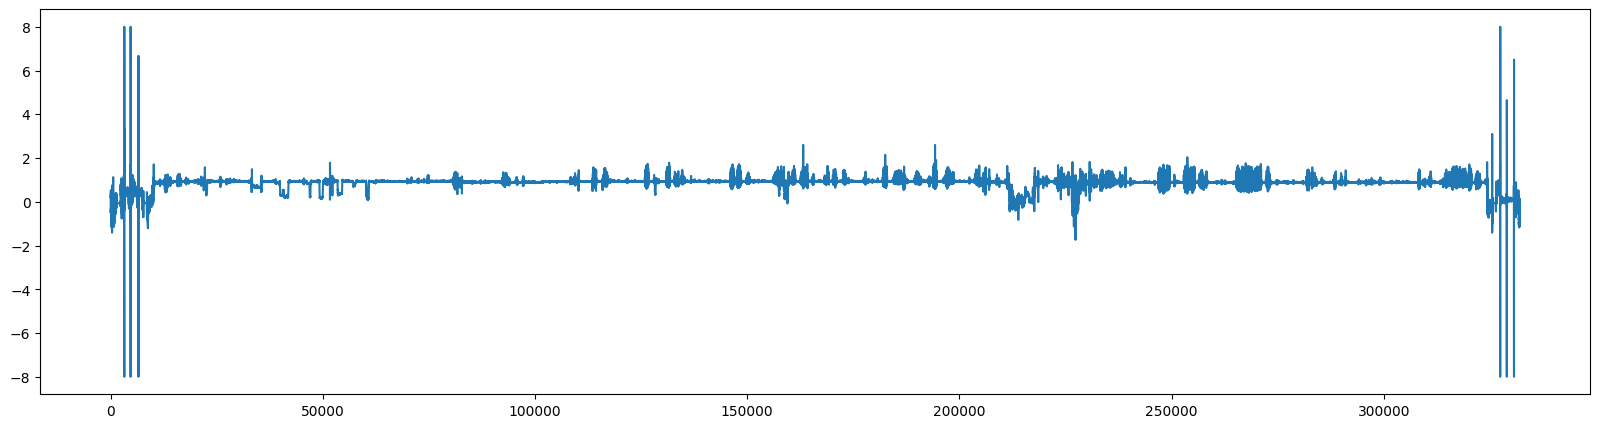

In [6]:
samples["accel_x"].plot(figsize = (20, 5)) # note that figsize contains the x and y sizes for the figure. Have a play with these to see what happens.

This plot is great for just having a basic look that we've got anything, but it's really not ideal for looking at specific parts. Also, the x-axis is in _samples_ rather than _time_. Look at the following cell to see how we can fix this, and have a play with the ```start_id``` and ```end_id``` values to plot different regions. Take a look at our previous graph and recall that the x axis refers to the samples, if you see a region you're interested in, use the x axis to figure out what start and end values you need to look at.

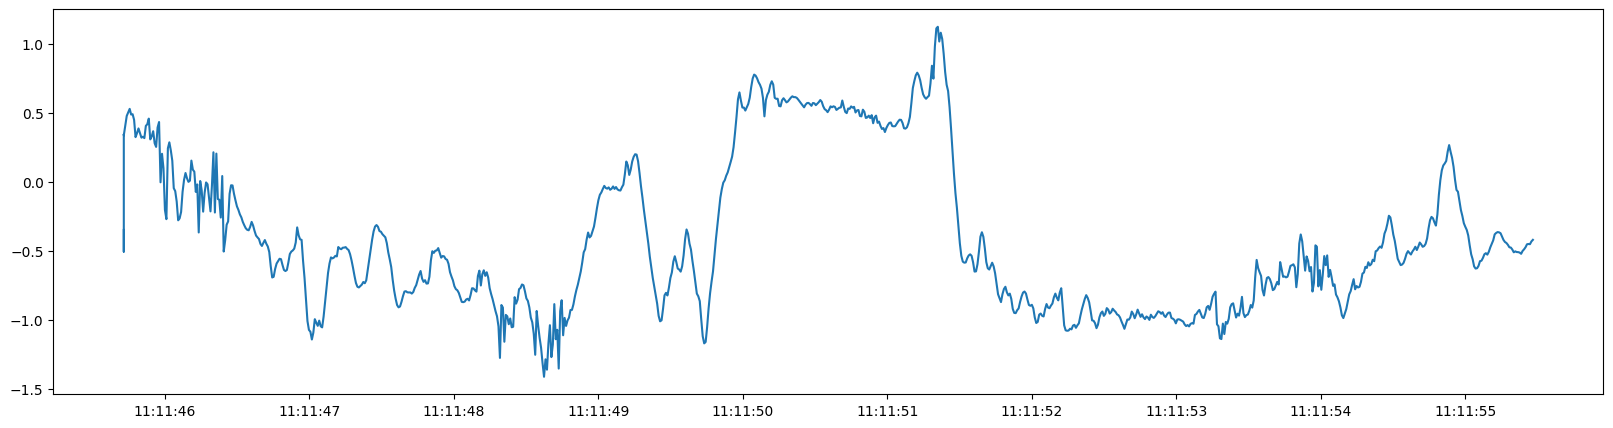

In [7]:
import matplotlib.pyplot as plt    # we'll use matplotlib for this plot

start_id = 0    # the first point we want to plot - feel free to change
end_id = 1000   # the last point we want to plot - feel free to change

samples_to_plot = samples.iloc[start_id:end_id] # here we make a copy of our table, but use iloc to get just the values from the start_id to the end_id

plt.figure(figsize=(20, 5))                                   # first, we tell matplotlib how big the figure will be.
plt.plot(samples_to_plot["time"], samples_to_plot["accel_x"]) # next, we plot the x and y axes as columns from our table
plt.show()                                                    # finally, we show the figure

### 2.4. Formatting Our Data for MobGap

So, now we've seen how to import our data from ".cwa" files and look at the data, we now need to get this data into a format that MobGap can work with. This step is more complicated than I'd like it to be, but basically we need to build a very specific folder structure. We'll break this down into lots of steps to make sure you know exactly what's going on throughout this process.

First thing to note is that MobGap prefers to be given data in a ".mat" file format. This is the native format for storing data and variables in a program called MATLAB. If we were dealing in MATLAB now, this would make life very easy but, because we're not, it's going to make life very hard.

But don't worry! We already have our ".cwa" data imported in the variable "samples" so we just need to save this to a ".mat" file by structuring it correctly. Let's start with the time:

#### 2.4.1. Reformatting Time
Mobgap likes time to be given as a 2D array of samples, each of which is in unix time. Unix time just means the number of seconds since midnight on the 1st of January 1970, which is called the "unix epoch". We can do this by casting our time column to the datatype "int64" which is a 64-bit integer. This gives us the number of nanoseconds since the unix epoch, so to convert into seconds, we divide by 1 billion ($10^9$).

Once our samples are the correct numbers, we need to make them the correct shape (2D array), we can do this with the "reshape" function. This function takes the arguments "(-1, 1)" which means we're getting a 2D array with as many rows as needed (that's what the -1 means) and just 1 column.

In [8]:
reformatted_time = samples["time"].astype('int64') // 10**9  # convert nanoseconds to seconds       
reformatted_time = reformatted_time.values.reshape(-1, 1)

display(reformatted_time)

array([[1754565105],
       [1754565105],
       [1754565105],
       ...,
       [1754568481],
       [1754568481],
       [1754568481]], shape=(332040, 1))

Next, let's get the start date, which we will also need to save into MobGap. This is stored in a more human-readable format. For this, we get the first element in the "time" column using ```.iloc[0]```, then we format the time using the string ```'%d-%b-%Y %H:%M:%S'``` which contains:
- %d: - Day as a 0-padded decimal
- %b: - Month abbreviated to just 3 characters
- %Y: - Year with centuary
- %H: - Hour (24-hour clock) as a zero-padded decimal.
- %M: - Minute as a zero-padded decimal.
- %S: - Second as a zero-padded decimal.

Our hyphons, colons, and spaces remain as they are. 

In [9]:
start_date_time = samples["time"].iloc[0].strftime('%d-%b-%Y %H:%M:%S')
print(start_date_time)

07-Aug-2025 11:11:45


#### 2.4.2. Sample Frequency

Next we need our sample frequency. The sensors we're using are supposed to be capturing data at 100 Hz (100 samples per second). However, it's very common for this to shift by 0.1 Hz or more. For small numbers of samples, this wouldn't be noticable, but for recordings spanning several days, this will be a significantly larger problem. Let's calculate our sample rate from the data by taking the total number of samples (```len(samples)```) and dividing this by the difference between the last and the first timestamp (the time elapsed). We then take the ```floor()``` of this value to round it down to a whole number:

In [10]:
fs = len(samples)/(reformatted_time[-1][0] - reformatted_time[0][0])
print(fs)

98.35308056872037


#### 2.4.3. Building a ".mat" File

Next, we need to structure our ".mat" file. Generally, these files are defined hierachies in which the actual data is stored along with the trial number, test number/name, and time measure or timepoint that the measurement was taken at. The structure looks like so:
```
data/
└── TimeMeasure/
    └── Test/
        └── Trial/
            ├── SU/
            │   └── LowerBack/
            │       ├── Fs/
            │       │   ├── Acc
            │       │   └── Gyr
            │       ├── Acc
            │       ├── Gyr
            │       └── Timestamp
            ├── StartDateTime
            └── TimeZone
```

In the following cell, we build a Python dictionary which follows this layout:

In [11]:
data = {
    "TimeMeasure1": {
        "Test1": {
            "Trial1": {
                "SU": {
                    "LowerBack": {
                        "Fs": {
                            "Acc": fs,
                            "Gyr": fs
                        },
                        "Acc": samples[["accel_x", "accel_y", "accel_z"]].values,
                        "Gyr": samples[["gyro_x", "gyro_y", "gyro_z"]].values,
                        "Timestamp": reformatted_time
                    }
                }, 
                "StartDateTime": start_date_time,
                "TimeZone": "Europe/UK"
            }
        }
    }
}

data = {"data": data}

Along with the "data" file, we also need some metadata about the person wearing the sensor which will be used in the machine learning and other algorithms that MobGap uses to calculate digital mobility outcomes. Run the following cell, which will ask you to input these details about yourself:

In [12]:
gender = input("Gender (M/F): ")
handedness = input("Handedness (R/L): ")
age = int(input("Age: "))
weight = float(input("Weight (kg): "))
height = float(input("Height (cm): "))
sensor_height = float(input("Sensor Height (cm): "))

infoForAlgo = {
    "TimeMeasure1": {
        "Subject_ID": "1",
        "Cohort": "HA",
        "Gender": gender,
        "Handedness": handedness,
        "Age": age,
        "Weight": weight,
        "Height": height,
        "SensorHeight": sensor_height,
        "WalkingAid_01": 0,
        "WalkingAid_Side": "",
        "WalkingAid_Description": "",
        "SensorType_SU": "AX6",
        "SensorAttachment_SU": "Body-Worn"
    }
}

infoForAlgo = {"infoForAlgo": infoForAlgo}

Gender (M/F):  M
Handedness (R/L):  R
Age:  27
Weight (kg):  80
Height (cm):  180
Sensor Height (cm):  100


Great, we've now got all the data we need to build a MobGap dataset. But we're not done yet - MobGap uses the folders that the ".mat" files are stored in as additional metadata. This means that we need to build an appropriate folder structure before we save our ".mat" file, so that MobGap will know where to find it and derive this additional metadata from the folder names. The folder structure itself is up to us, as long as it contains the subject number and cohort. To make this as simple as possible, let's just include those fields, meaning that our folder structure will look like so:
```
└── Current Folder/
    ├── Dataset/
    │   └── HA/
    │       └── 1/
    │           ├── data.mat
    │           └── infoForAlgo.mat
    ├── This_Python_File.ipynb
    └── Your_Data_File.cwa
```

We can create these folders with code using the "os" library that we used in section 2.2:

In [13]:
current_dir = os.getcwd()                                   # get current working directory (cwd)
target_dir = os.path.join(current_dir, r'Dataset/HA/1')     # define the target directory relative to the current directory
if not os.path.exists(target_dir):                          # check if the folders already exist
   os.makedirs(target_dir)                                  # if they dont, make the folders

Now, check the folder that this file is in, you should be able to see the new "Dataset" folder, which contains "HA", and then "1".

Next, we'll save our ".mat" files in this directory using scipy's "savemat" function:

In [14]:
from scipy.io import savemat

savemat(target_dir + "\\infoForAlgo.mat", infoForAlgo)
savemat(target_dir + "\\data.mat", data)

Great, we should now (finally) be all ready to build a MobGap dataset from our data. The next section will walk you through how to do this and some of the nice functions we have inside MobGap to look at and characterise our walking.

## 3. MobGap

### 3.1. Creating a MobGap Dataset Object

Let's build our MobGap dataset using the GenericMobilisedDataset constructor from the mobgap library. We need to give this constructor a list of paths to all of our mat files, so we'll use our "get_paths_with_extension" function from earlier:

In [15]:
mat_files = get_paths_with_extension(".mat")
mat_files = [file for file in mat_files if file.endswith("data.mat")]

dataset = GenericMobilisedDataset(
    paths_list = mat_files,
    test_level_names = ["TimeMeasure", "Test", "Trial"], # This is the structure (without numbers) of the data inside the data.mat struct.
    measurement_condition = "laboratory",
    parent_folders_as_metadata=["dataset", "cohort", "subject"] # these are the column headings for the metadata, the columns get populated with the folder names.
)

display(dataset)

C:\Users\ac4jmi\anaconda3\envs\mobgap_fixed\Lib\site-packages\mobgap\data\_mobilised_matlab_loader.py:1245: UserWarning: Global caching is a little tricky to get right and our implementation is not yet battle-tested. Please double check that the results are correct and report any issues you find.
  return hybrid_cache(self.memory, 1)(_load_test_data_without_checks)(


,dataset,cohort,subject,TimeMeasure,Test,Trial
0,Dataset,HA,1,TimeMeasure1,Test1,Trial1


Finally! We have our MobGap dataset. From here on out, everything gets much easier as our data is now in a standardised form so we can just run our pipelines and algorithms on the dataset. Let's start with running a simple pipeline and extracting some digital mobility outcomes from our walking:

In [16]:
pipeline = MobilisedPipelineHealthy()
pipeline = pipeline.safe_run(dataset)
print("Pipeline finished running!")

Pipeline finished running!


The following 2 cells will display the aggregated parameters (the DMOs) and the per-walking-bout parameters respectively.

In [17]:
display(pipeline.aggregated_parameters_) # all parameters across all walking bouts

,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,49,10.425872,944,9.272714,23.828435,0.871317,84.096555,1.302241,0.120816,0.157286,...,3,0.887625,1.11413,92.916313,1.237842,1.063488,99.863762,0.245929,0.165122,1


In [18]:
display(pipeline.per_wb_parameters_.head(5))     # first 5 per-walking-bout parameters

,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,17427,18320,9,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",9.079533,12,1.206537,NaN,0.481373,NaN
1,92115,93451,16,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",13.583713,18,1.489531,73.366444,0.807225,0.480624
2,108317,108723,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.127985,6,1.713215,65.394754,0.781771,0.450452
3,109131,109588,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.646525,6,1.560704,NaN,0.644586,NaN
4,113605,114387,10,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.950946,12,1.192642,86.012530,1.169261,0.844198


Notice how we have more columns (hopefully 25) in the aggregated parameters than we do in the per-wb-parameters. This is because our aggregated parameters combine our per-wb-parameters in multiple ways. For example, total walking duration is the sum of all the durations of each walking bout, while "wb_all__duration_s__avg" is the average duration of each walking bout. Therefore, the duration_s parameter in the per-wb-parameters is used more than once.

Great! Now we have our total walking parameters which we can use to look at someone's overall gait, and our per-walking-bout parameters which can be used for more detail. In the next section, we'll dig a little deeper into those per-wb parameters!

### 3.2. Per-WB Statistics

Let's take our per-wb parameters and plot some graphs to see the distributions of our walking bouts. We'll start with a simple histogram that shows the distribution of cadence in each of our walking bouts.

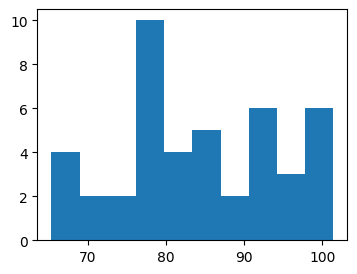

In [30]:
plt.figure(figsize = (4, 3))
plt.hist(pipeline.per_wb_parameters_["cadence_spm"], bins = 10)
plt.show()

#### Exercise
In the following cell, copy the code for the histogram above and change it to show **5 bins** which display the distribution of **stride lengths** over each walking bout. Remember to check the tables we displayed earlier to see the column heading names!

#### Exercise
In the following cell, copy the code for the histogram again, but this time let's change it to a **box plot** showing the **number of strides**.

To change from a histogram to a box plot, simply replace ```plt.hist(...)``` with ```plt.boxplot(...)``` and delete ```bins = 10```.

You may wish to change the ```figsize = (x, y)``` to be a bit taller.

As you may already know, our boxplot shows the mean number of strides, the interquartile range, and any outliers - expressed with little circles. Now imagine if we had the data from 100 different people, half of which have a neurological condition like cerebral palsy, and the other half who are healthy adults. By doing a box plot for each cohort, we can compare stats like the mean and interquartile range between these two groups to compare how they walk.

We can also make box plots to compare individual people to one another, or to compare a person's walking to themselves at a later point in time. If we see the mean number of strides go down after a 6 month gap between appointments, we know that person is walking less in their daily life, and doctors can give advice depending on this change in behaviour.